In [94]:
import os
import shutil
import subprocess

os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

print("LaTeX path:", shutil.which("latex"))
print(subprocess.run(
    ["latex", "--version"],
    capture_output=True,
    text=True
).stdout.splitlines()[0])

import numpy as np
import matplotlib.pyplot as plt

plt.rcdefaults()

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
})

LaTeX path: /Library/TeX/texbin/latex
pdfTeX 3.141592653-2.6-1.40.29 (TeX Live 2026)


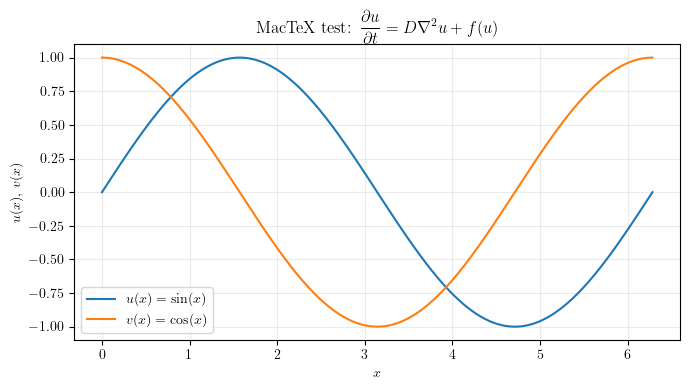

In [95]:
from pathlib import Path

# This notebook and the CSV files are stored in the same directory.
data_dir = Path(".")
tcorr_ranges = [
    "0p5_to_1p4",
    "1p5_to_2p4",
    "2p5_to_3p4",
    "3p5_to_4p4",
    "4p5_to_5p4",
]

def load_combined_matrix(prefix):
    blocks = [
        np.loadtxt(
            data_dir / f"{prefix}_tv_1_to_50_step_1_tcorr_{tcorr_range}_step_0p1.csv",
            delimiter=",",
        )
        for tcorr_range in tcorr_ranges
    ]
    combined = np.hstack(blocks)
    if combined.shape != (50, 50):
        raise ValueError(f"Expected {prefix} to have shape (50, 50), got {combined.shape}")
    return combined

# Rows correspond to t_v; columns correspond to t_corr.
pdmat = load_combined_matrix("pdmat")
pltmat = load_combined_matrix("pltmat")
prpmat = load_combined_matrix("prpmat")

t_v = np.arange(1, 51)
t_corr = np.round(np.arange(0.5, 5.5, 0.1), 1)

print("pdmat shape: ", pdmat.shape)
print("pltmat shape:", pltmat.shape)
print("prpmat shape:", prpmat.shape)

pdmat shape:  (50, 50)
pltmat shape: (50, 50)
prpmat shape: (50, 50)


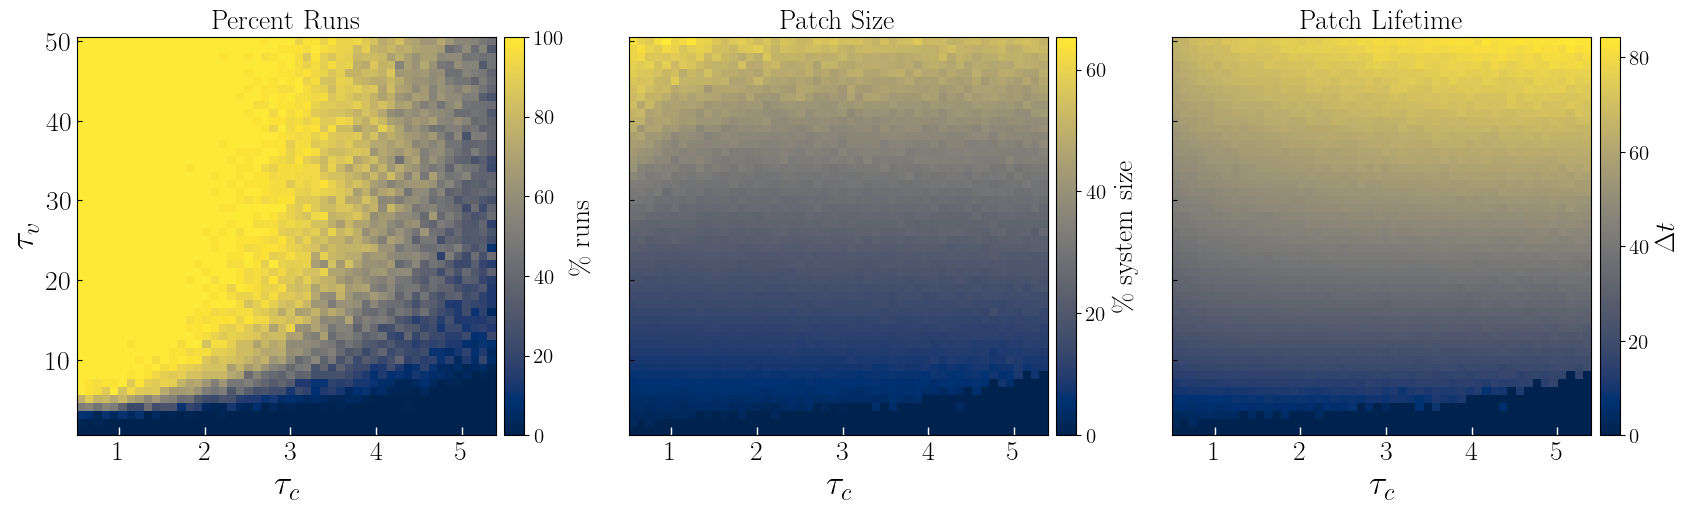

In [112]:
# Phase diagrams: t_corr along x, t_v along y.
# Zero entries use the lowest color on each color scale.
total_system_pixels = 1000
patch_size_percent = 100 * pdmat / total_system_pixels
matrices = [prpmat, patch_size_percent, pltmat]
titles = [r"$\text{Percent Runs}$", r"$\text{Patch Size}$", r"$\text{Patch Lifetime}$"]
colorbar_labels = [r"$\text{\% runs}$", r"$\text{\% system size}$", r"$\Delta t$"]

# Cell edges place the data values at the centers of the colored cells.
t_corr_edges = np.linspace(t_corr[0], t_corr[-1], len(t_corr) + 1)
t_v_edges = np.arange(0.5, 51.5, 1.0)

cmap_names = ["cividis", "cividis", "cividis"]
colorbar_steps = [None, 20, 20]

fig, axes = plt.subplots(
    1, 3, figsize=(17, 5), sharex=True, sharey=True, constrained_layout=True
)
fig.set_constrained_layout_pads(w_pad=0.15, wspace=0.06)

for ax, matrix, title, cbar_label, cmap_name, cbar_step in zip(
    axes, matrices, titles, colorbar_labels, cmap_names, colorbar_steps
):
    cmap = plt.get_cmap(cmap_name).copy()
    mesh = ax.pcolormesh(
        t_corr_edges,
        t_v_edges,
        matrix,
        cmap=cmap,
        vmin=0,
        shading="flat",
        rasterized=True,
    )
    ax.set_title(title, fontsize=20)
    ax.set_xlabel(r"$\tau_c$", fontsize=25)
    ax.set_xlim(t_corr[0], t_corr[-1])
    ax.set_ylim(0.5, 50.5)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.tick_params(direction="in", top=False, right=False, labelsize=20)
    ax.tick_params(
        axis="x", color="white", labelcolor="black", length=6, width=1
    )

    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    if cbar_step is not None:
        highest_tick = cbar_step * np.floor(np.nanmax(matrix) / cbar_step)
        cbar.set_ticks(np.arange(0, highest_tick + cbar_step, cbar_step))
    cbar.set_label(cbar_label, fontsize=20)
    cbar.ax.tick_params(labelsize=15)

axes[0].set_ylabel(r"$\tau_v$", fontsize=25)
plt.show()

# Optional publication-quality output:
fig.savefig("phase_diagrams.pdf", bbox_inches="tight")
# fig.savefig("phase_diagrams.png", dpi=300, bbox_inches="tight")

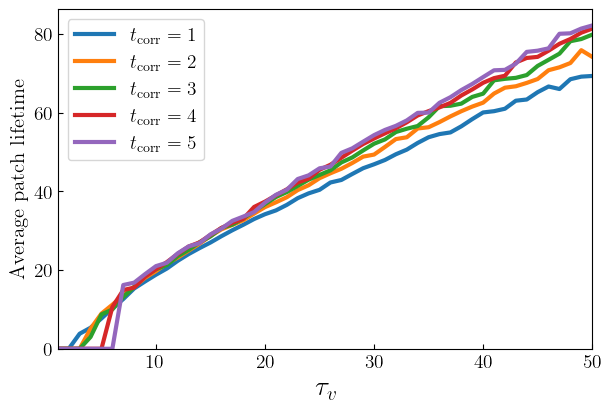

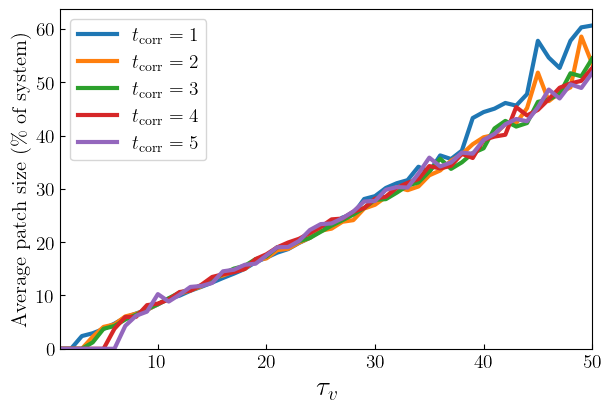

In [108]:
# Patch lifetime and size versus t_v at selected correlation times.
selected_t_corr = [1.0, 2.0, 3.0, 4.0, 5.0]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
total_system_pixels = 1000

def tcorr_column(value):
    matches = np.flatnonzero(np.isclose(t_corr, value))
    if len(matches) != 1:
        raise ValueError(f"Could not uniquely locate t_corr = {value}")
    return matches[0]

# Average patch lifetime.
fig_lifetime, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
for value, color in zip(selected_t_corr, colors):
    column = tcorr_column(value)
    ax.plot(
        t_v, pltmat[:, column],
        color=color, linewidth=3,
        label=rf"$t_{{\mathrm{{corr}}}}={value:g}$",
    )
ax.set_xlabel(r"$\tau_v$", fontsize=20)
ax.set_ylabel(r"Average patch lifetime", fontsize=15)
ax.set_xlim(t_v[0], t_v[-1])
ax.set_ylim(bottom=0)
ax.tick_params(direction="in", top=False, right=False, labelsize=14)
ax.legend(frameon=True, fontsize=14)
plt.show()

# Average patch spatial size.
fig_size, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
for value, color in zip(selected_t_corr, colors):
    column = tcorr_column(value)
    ax.plot(
        t_v, 100 * pdmat[:, column] / total_system_pixels,
        color=color, linewidth=3,
        label=rf"$t_{{\mathrm{{corr}}}}={value:g}$",
    )
ax.set_xlabel(r"$\tau_v$", fontsize=20)
ax.set_ylabel(r"Average patch size (\% of system)", fontsize=15)
ax.set_xlim(t_v[0], t_v[-1])
ax.set_ylim(bottom=0)
ax.tick_params(direction="in", top=False, right=False, labelsize=14)
ax.legend(frameon=True, fontsize=14)
plt.show()

# Optional publication-quality output:
fig_lifetime.savefig("patch_lifetime_vs_tv.pdf", bbox_inches="tight")
fig_size.savefig("patch_size_vs_tv.pdf", bbox_inches="tight")

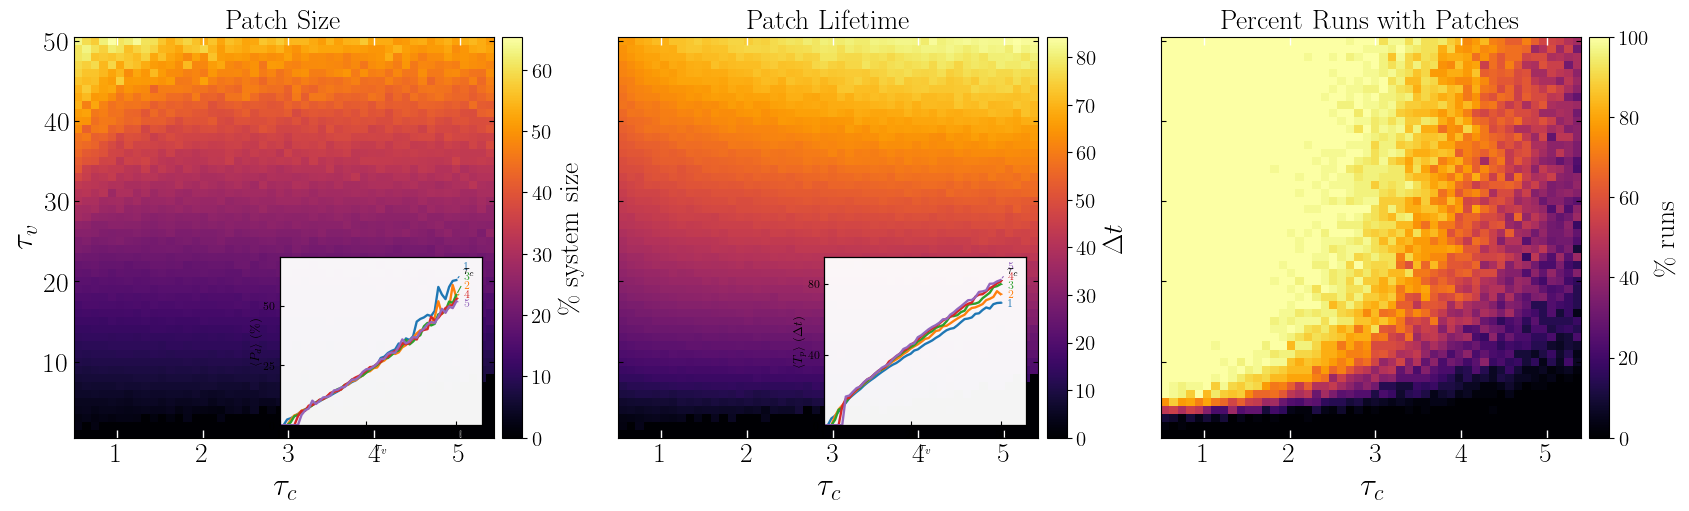

In [98]:
# Experimental version: phase diagrams with compact line-plot insets.
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

total_system_pixels = 1000
patch_size_percent = 100 * pdmat / total_system_pixels
phase_matrices = [patch_size_percent, pltmat, prpmat]
phase_titles = [
    r"$\text{Patch Size}$",
    r"$\text{Patch Lifetime}$",
    r"$\text{Percent Runs with Patches}$",
]
phase_cbar_labels = [
    r"$\text{\% system size}$",
    r"$\Delta t$",
    r"$\text{\% runs}$",
]
selected_t_corr = [1.0, 2.0, 3.0, 4.0, 5.0]
curve_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

t_corr_edges = np.linspace(t_corr[0], t_corr[-1], len(t_corr) + 1)
t_v_edges = np.arange(0.5, 51.5, 1.0)

def tcorr_column(value):
    matches = np.flatnonzero(np.isclose(t_corr, value))
    if len(matches) != 1:
        raise ValueError(f"Could not uniquely locate tau_c = {value}")
    return matches[0]

def separated_label_positions(values, upper, minimum_gap):
    """Spread endpoint labels vertically while preserving their order."""
    values = np.asarray(values, dtype=float)
    order = np.argsort(values)
    positions = values[order].copy()
    for i in range(1, len(positions)):
        positions[i] = max(positions[i], positions[i - 1] + minimum_gap)
    if positions[-1] > upper:
        positions -= positions[-1] - upper
    result = np.empty_like(positions)
    result[order] = positions
    return result

def add_curve_inset(parent_ax, matrix, ylabel, convert_to_percent=False):
    inset = inset_axes(
        parent_ax, width="48%", height="42%",
        loc="lower right", borderpad=0.9,
    )
    inset.set_facecolor("white")
    inset.patch.set_alpha(0.96)

    curves = []
    for value in selected_t_corr:
        curve = matrix[:, tcorr_column(value)].copy()
        if convert_to_percent:
            curve = 100 * curve / total_system_pixels
        curves.append(curve)

    ymax = max(curve.max() for curve in curves)
    inset_upper = 1.16 * ymax
    endpoint_values = [curve[-1] for curve in curves]
    label_positions = separated_label_positions(
        endpoint_values, inset_upper * 0.94, inset_upper * 0.055
    )

    for value, color, curve, label_y in zip(
        selected_t_corr, curve_colors, curves, label_positions
    ):
        inset.plot(t_v, curve, color=color, linewidth=1.7)
        inset.annotate(
            f"{value:g}", xy=(t_v[-1], curve[-1]), xytext=(52, label_y),
            color=color, fontsize=8, ha="left", va="center",
            arrowprops=dict(arrowstyle="-", color=color, linewidth=0.8),
            annotation_clip=True,
        )

    inset.text(0.96, 0.95, r"$\tau_c$", transform=inset.transAxes,
               fontsize=9, ha="right", va="top")
    inset.set_xlim(1, 57)
    inset.set_ylim(0, inset_upper)
    inset.set_xticks([1, 25, 50])
    inset.yaxis.set_major_locator(MaxNLocator(3))
    inset.set_xlabel(r"$\tau_v$", fontsize=10, labelpad=1)
    inset.set_ylabel(ylabel, fontsize=9, labelpad=1)
    inset.tick_params(direction="in", top=False, right=False,
                      labelsize=8, length=3, width=0.8)
    for spine in inset.spines.values():
        spine.set_linewidth(0.9)
    return inset

fig_insets, axes = plt.subplots(
    1, 3, figsize=(17, 5), sharex=True, sharey=True, constrained_layout=True
)
fig_insets.set_constrained_layout_pads(w_pad=0.15, wspace=0.06)

for ax, matrix, title, cbar_label in zip(
    axes, phase_matrices, phase_titles, phase_cbar_labels
):
    mesh = ax.pcolormesh(
        t_corr_edges, t_v_edges, matrix, cmap="inferno", vmin=0,
        shading="flat", rasterized=True,
    )
    ax.set_title(title, fontsize=20)
    ax.set_xlabel(r"$\tau_c$", fontsize=23)
    ax.set_xlim(t_corr[0], t_corr[-1])
    ax.set_ylim(0.5, 50.5)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.tick_params(direction="in", top=True, right=True, labelsize=20)
    ax.tick_params(axis="x", color="white", labelcolor="black",
                   length=6, width=1)
    cbar = fig_insets.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(cbar_label, fontsize=20)
    cbar.ax.tick_params(labelsize=15)

axes[0].set_ylabel(r"$\tau_v$", fontsize=23)

# Insets are placed over the low-tau_v region, where the phase maps are simplest.
add_curve_inset(
    axes[0], pdmat, r"$\langle P_d\rangle$ (\%)", convert_to_percent=True
)
add_curve_inset(
    axes[1], pltmat, r"$\langle T_p\rangle$ ($\Delta t$)"
)

plt.show()

# Optional publication-quality output:
# fig_insets.savefig("phase_diagrams_with_insets.pdf", bbox_inches="tight")
# fig_insets.savefig("phase_diagrams_with_insets.png", dpi=300, bbox_inches="tight")